In [35]:
%matplotlib inline

<div class="alert alert-info"><h4>Further reading:</h4><p>This notebook is adapted from the <a href="https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html">PyTorch: A 60 Minute Blitz</a> tutorial on the PyTorch website. For documentation and more tutorials, visit <a href="https://pytorch.org">pytorch.org</a></p></div>

# Neural Networks

This notebook demonstrates a training step in PyTorch using **random inputs and targets**. It does not train a digit classifier; the goal is to understand how predictions, loss, gradients, and weight updates fit together.

We use a small convolutional network based on [LeNet](https://doi.org/10.1109%2F5.726791), an architecture designed for handwritten digit recognition:

![convnet](mnist_cnn.png)

Check the interesting history behind LeNet [here](https://en.wikipedia.org/wiki/LeNet)!


## Summary

1. **Define the network and compute predictions** — declare layers in `nn.Module` and connect them in `forward`.
2. **Compute the loss** — compare predictions with a target using mean-squared error.
3. **Backpropagate** — clear old gradients, then use `loss.backward()` to compute new ones.
4. **Update the weights** — apply gradient descent by hand, then see how an optimizer handles the same operation.


## 1. Define the network

Let’s define this network:

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()
        # first some convolutions (see lecture notes for details on convolution)
        # 1 input image channel, 6 output channels, 5x5 square convolution kernel
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5) # 6 in, 16 out, 5x5 convolution
        
        # Next some linear (technically "affine") operations, y = Wx + b
        # 16x5x5 in (see diagram above), 120 out
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84) # 120 in, 84 out
        self.fc3 = nn.Linear(84, 10) # 84 in, 10 out

    def forward(self, x):
        # given input x (an image, for example), apply the first convolution
        x = self.conv1(x)
        # then apply a relu activation function
        x = F.relu(x)
        # then subsample with a 2x2 max pooling window
        x = F.max_pool2d(x, 2)
        # repeat with the second convolution
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        # flatten the dimensions beyond the first (that's the batch dimension)
        x = torch.flatten(x, 1)
        # pass through the linear operations, with relus in between
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [37]:
net = Net()
print(net)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


We define the `forward` to compute predictions, and the `backward` functions (where gradients are computed) is automacally defined for us with  `autograd`.

`net.parameters()` returns the learnable parameter tensors:


In [38]:
params = list(net.parameters())
print("number of parameter tensors:", len(params))
print("size of first parameter (conv1's weight):", params[0].size())


number of parameter tensors: 10
size of first parameter (conv1's weight): torch.Size([6, 1, 5, 5])


Let's pass one random image through the network. The input shape is `(batch size, channels, height, width)`, so `(1, 1, 32, 32)` means one grayscale 32×32 image.

The convolutions and pooling reduce 32×32 to 5×5, with 16 channels. Flattening gives the 400 values expected by `fc1`. Standard 28×28 MNIST images would need padding or resizing to 32×32 for this example.

The output contains 10 scores per image, one for each possible digit. These are raw scores, not probabilities.


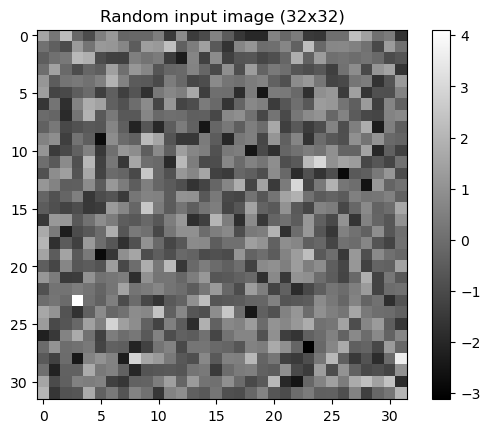

tensor([[-0.1290,  0.0556,  0.0578,  0.0361,  0.0019,  0.1476,  0.0575,  0.0688,
         -0.0974,  0.0342]], grad_fn=<AddmmBackward0>)


In [39]:
import matplotlib.pyplot as plt

input = torch.randn(1, 1, 32, 32) # 1 image, 1 channel, with dimensions 32x32

# visualize the input: drop the batch and channel dims to get a 32x32 image
plt.imshow(input[0, 0], cmap='gray')
plt.colorbar()
plt.title('Random input image (32x32)')
plt.show()

output = net(input)
print(output)

## 2. Loss Function

A loss function measures how far the network's predictions (output) are from a target.

There are several different loss functions under the nn package.

Here we use `nn.MSELoss`, which computes the mean-squared error between the output and target values.

Our target is a random vector of 10 values with the same shape as the output. 

In [ ]:
target = torch.randn(1, 10)  # dummy target with the same shape as output
print(target)

criterion = nn.MSELoss()  # construct the loss function

loss = criterion(output, target)
print(loss)


tensor([[ 0.5028, -0.0837, -0.0307, -0.8694, -1.0367, -0.7239,  0.0913,  0.6032,
         -0.3893,  0.7851]])
tensor(0.3986, grad_fn=<MseLossBackward0>)


Now, if you follow ``loss`` in the backward direction, using its ``.grad_fn`` attribute, you will see a graph of computations that look like this:

    input -> conv2d -> relu -> maxpool2d -> conv2d -> relu
          -> maxpool2d -> flatten -> linear -> relu -> linear
          -> relu -> linear -> MSELoss -> loss

So, when we call ``loss.backward()``, the whole graph is differentiated
w.r.t. the neural net parameters, and all Tensors in the graph that have
``requires_grad=True`` will have their ``.grad`` Tensor accumulated with the
gradient.

For illustration, let's follow a few steps backward:

## 3. Backprop

To backpropagate the error all we have to do is call ``loss.backward()``. We'll first need to clear the existing gradients though, or else the new gradients will be accumulated with the existing gradients.

Let's look at conv1's bias gradients before and after the backward.


In [41]:
net.zero_grad(set_to_none=True)  # clear any gradients from previous steps

print('conv1.bias.grad before backward')
print(net.conv1.bias.grad)

loss.backward()

print('conv1.bias.grad after backward')
print(net.conv1.bias.grad)

conv1.bias.grad before backward
None
conv1.bias.grad after backward
tensor([ 0.0130,  0.0131,  0.0185, -0.0087,  0.0034, -0.0184])


**Read Later:** The neural network package contains various modules and loss functions that form the building blocks of deep neural networks. A full list with documentation is [here](https://pytorch.org/docs/nn).

## 4. Update the weights

A simple update rule is Stochastic Gradient Descent (SGD):

### 4.1 Stochastic Gradient Descent by hand

Gradient descent uses the gradients to adjust each parameter in the direction that reduces the loss locally:

`weight = weight - learning_rate * gradient`

We use `torch.no_grad()` because the update itself should not become part of the computation graph.


In [42]:
learning_rate = 0.01
with torch.no_grad():
    for parameter in net.parameters():
        parameter -= learning_rate * parameter.grad


In practice, though, there's a package called ``torch.optim`` that implements this and many other update rules for us:

### 4.2 Using `torch.optim`

The code below shows the complete training-step pattern: clear gradients → predict → compute loss → backpropagate → update.

The manual update above and `optimizer.step()` are alternative ways to update the weights. Running both sections performs two successive updates; in a training loop, use just one method.


In [ ]:
import torch.optim as optim

# create your optimizer

optimizer = optim.SGD(net.parameters(), lr=0.01)

# in your training loop:
optimizer.zero_grad()  # clear old gradients
output = net(input)  # compute fresh predictions with the current weights
loss = criterion(output, target)
loss.backward()  # compute gradients
optimizer.step()  # update the weights
